In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [19]:
# Create own dataset - Temperature vs Ice Cream Sales (non-linear relationship)
np.random.seed(42)

df = pd.read_csv("polynomial.csv")

# df = pd.DataFrame({'Temperature': temperature, 'Sales': sales})

print("Dataset shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nDataset statistics:")
print(df.describe())

Dataset shape: (30, 2)

First 10 rows:
   Temperature  Sales
0            5     20
1           10     30
2           15     50
3           20     85
4           25    130
5           30    190
6           35    270
7           40    360
8            8     25
9           12     40

Dataset statistics:
       Temperature       Sales
count    30.000000   30.000000
mean     22.533333  134.733333
std      10.354853  102.484964
min       5.000000   20.000000
25%      14.250000   51.250000
50%      21.500000   97.500000
75%      30.750000  197.500000
max      40.000000  360.000000


In [20]:
# Separate features and target
X = df[['Temperature']].values
y = df['Sales'].values

print("Features (X) - Temperature:")
print(X[:5])
print("\nTarget (y) - Sales:")
print(y[:5])

Features (X) - Temperature:
[[ 5]
 [10]
 [15]
 [20]
 [25]]

Target (y) - Sales:
[ 20  30  50  85 130]


In [21]:
# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 24
Test set size: 6


In [22]:
# Train Polynomial Regression model with degree 2
degree = 2

# Transform features to polynomial features
poly_features = PolynomialFeatures(degree=degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Train the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

print(f"Polynomial Regression model trained with degree {degree}")
print(f"Number of features after transformation: {X_train_poly.shape[1]}")

Polynomial Regression model trained with degree 2
Number of features after transformation: 3


In [23]:
# Make predictions
y_pred = model.predict(X_test_poly)

print("Predictions on test set:")
print("Temperature | Actual Sales | Predicted Sales")
print("-" * 45)
for i in range(len(y_test)):
    print(f"{X_test[i][0]:11.1f} | {y_test[i]:12.1f} | {y_pred[i]:15.1f}")

Predictions on test set:
Temperature | Actual Sales | Predicted Sales
---------------------------------------------
       36.0 |        280.0 |           281.6
        7.0 |         22.0 |            27.6
       16.0 |         65.0 |            57.0
       19.0 |         80.0 |            76.7
        8.0 |         25.0 |            28.7
       12.0 |         40.0 |            38.4


In [24]:
# Calculate evaluation metrics (MSE, MAE, R2-Score)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"R2 Score (F2-Score): {r2:.4f}")

Evaluation Metrics:
MSE (Mean Squared Error): 20.62
MAE (Mean Absolute Error): 3.93
R2 Score (F2-Score): 0.9974


In [25]:
# Test the model with real data (new temperature values)
new_temps = np.array([[23], [32], [37]])
new_temps_poly = poly_features.transform(new_temps)
predicted_sales = model.predict(new_temps_poly)

print("Testing with new data:")
print("Temperature | Predicted Sales")
print("-" * 30)
for i in range(len(new_temps)):
    print(f"{new_temps[i][0]:11.0f}°C | {predicted_sales[i]:15.1f}")

Testing with new data:
Temperature | Predicted Sales
------------------------------
         23°C |           110.6
         32°C |           219.1
         37°C |           298.5


In [26]:
# Print Coefficient and Intercept values
print("Model Coefficients:")
feature_names = poly_features.get_feature_names_out(['Temperature'])
for i, name in enumerate(feature_names):
    print(f"{name}: {model.coef_[i]:.4f}")

print(f"\nIntercept: {model.intercept_:.4f}")
print(f"\nPolynomial equation (degree {degree}):")
print(f"Sales = {model.intercept_:.4f} + {model.coef_[1]:.4f}*Temp + {model.coef_[2]:.4f}*Temp²")

Model Coefficients:
1: 0.0000
Temperature: -3.0373
Temperature^2: 0.2743

Intercept: 35.3936

Polynomial equation (degree 2):
Sales = 35.3936 + -3.0373*Temp + 0.2743*Temp²


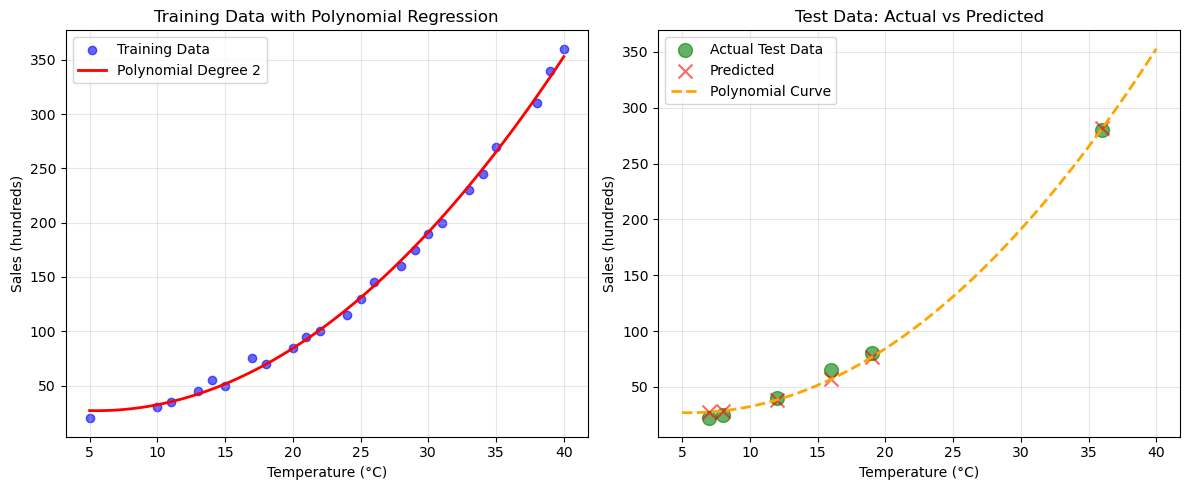

In [27]:
# Plot input features and regression line
plt.figure(figsize=(12, 5))

# Plot 1: Training data with polynomial curve
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)

# Create smooth curve for visualization
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_range = model.predict(X_range_poly)

plt.plot(X_range, y_range, color='red', linewidth=2, label=f'Polynomial Degree {degree}')
plt.xlabel('Temperature (°C)')
plt.ylabel('Sales (hundreds)')
plt.title('Training Data with Polynomial Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Test data with predictions
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='green', label='Actual Test Data', alpha=0.6, s=100)
plt.scatter(X_test, y_pred, color='red', label='Predicted', alpha=0.6, s=100, marker='x')
plt.plot(X_range, y_range, color='orange', linewidth=2, linestyle='--', label='Polynomial Curve')
plt.xlabel('Temperature (°C)')
plt.ylabel('Sales (hundreds)')
plt.title('Test Data: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Observe model performance by changing the degree
degrees = [1, 2, 3, 4, 5]
results = []

print("Performance comparison for different polynomial degrees:")
print("=" * 70)

for deg in degrees:
    # Transform features
    poly = PolynomialFeatures(degree=deg)
    X_train_p = poly.fit_transform(X_train)
    X_test_p = poly.transform(X_test)
    
    # Train model
    mdl = LinearRegression()
    mdl.fit(X_train_p, y_train)
    
    # Predict and evaluate
    y_p = mdl.predict(X_test_p)
    mse_d = mean_squared_error(y_test, y_p)
    mae_d = mean_absolute_error(y_test, y_p)
    r2_d = r2_score(y_test, y_p)
    
    results.append({'Degree': deg, 'MSE': mse_d, 'MAE': mae_d, 'R2': r2_d})
    print(f"Degree {deg}: MSE={mse_d:.2f}, MAE={mae_d:.2f}, R2={r2_d:.4f}")

print("=" * 70)

Performance comparison for different polynomial degrees:
Degree 1: MSE=674.66, MAE=21.33, R2=0.9157
Degree 2: MSE=20.62, MAE=3.93, R2=0.9974
Degree 3: MSE=5.07, MAE=1.77, R2=0.9994
Degree 4: MSE=4.84, MAE=1.62, R2=0.9994
Degree 5: MSE=3.60, MAE=1.26, R2=0.9996


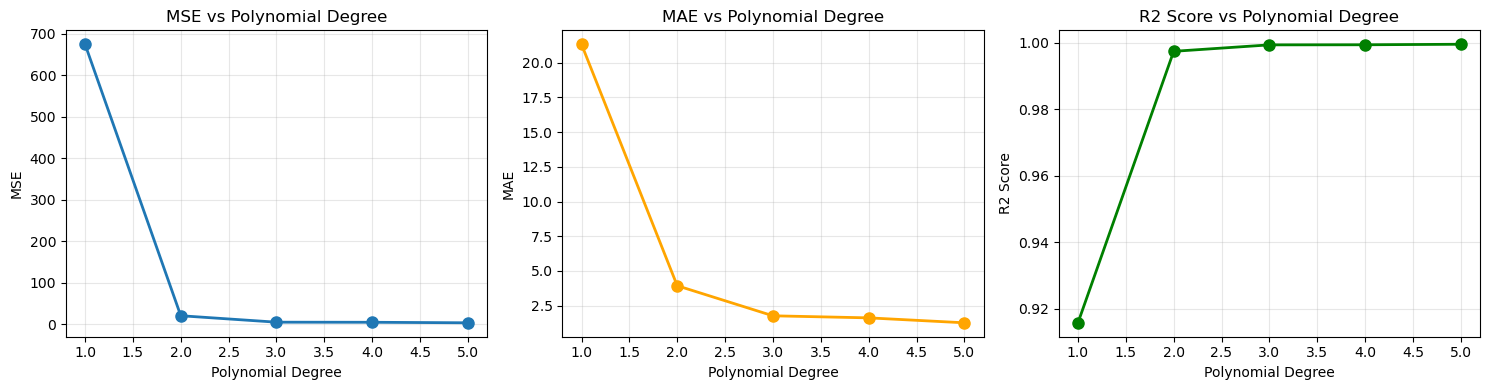

In [29]:
# Visualize performance across different degrees
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot MSE
axes[0].plot(results_df['Degree'], results_df['MSE'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE vs Polynomial Degree')
axes[0].grid(True, alpha=0.3)

# Plot MAE
axes[1].plot(results_df['Degree'], results_df['MAE'], marker='o', color='orange', linewidth=2, markersize=8)
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE vs Polynomial Degree')
axes[1].grid(True, alpha=0.3)

# Plot R2 Score
axes[2].plot(results_df['Degree'], results_df['R2'], marker='o', color='green', linewidth=2, markersize=8)
axes[2].set_xlabel('Polynomial Degree')
axes[2].set_ylabel('R2 Score')
axes[2].set_title('R2 Score vs Polynomial Degree')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

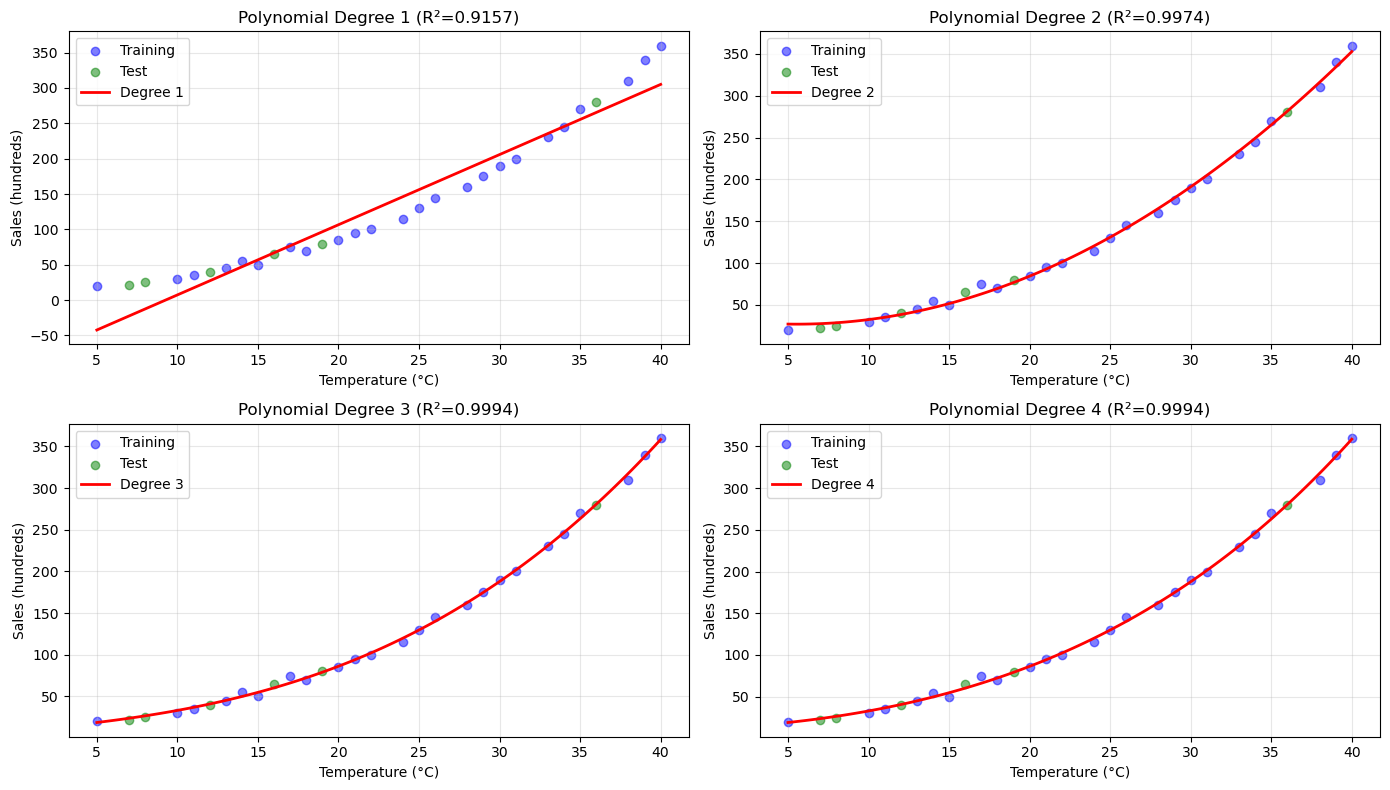

In [30]:
# Visual comparison of different polynomial degrees
plt.figure(figsize=(14, 8))

for i, deg in enumerate([1, 2, 3, 4], 1):
    plt.subplot(2, 2, i)
    
    # Transform and train
    poly = PolynomialFeatures(degree=deg)
    X_train_p = poly.fit_transform(X_train)
    X_test_p = poly.transform(X_test)
    mdl = LinearRegression()
    mdl.fit(X_train_p, y_train)
    
    # Plot data
    plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training')
    plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test')
    
    # Plot curve
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range = mdl.predict(X_range_poly)
    plt.plot(X_range, y_range, color='red', linewidth=2, label=f'Degree {deg}')
    
    # Calculate R2
    y_p = mdl.predict(X_test_p)
    r2_d = r2_score(y_test, y_p)
    
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Sales (hundreds)')
    plt.title(f'Polynomial Degree {deg} (R²={r2_d:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Discussion: Model Performance Analysis
print("=" * 70)
print("MODEL PERFORMANCE DISCUSSION")
print("=" * 70)

print("\n1. POLYNOMIAL REGRESSION CONCEPT:")
print("   Polynomial regression extends linear regression by adding polynomial")
print("   terms (x², x³, etc.) to capture non-linear relationships.")
print("   Formula: y = β₀ + β₁x + β₂x² + ... + βₙxⁿ")

print(f"\n2. CURRENT MODEL (Degree {degree}):")
print(f"   R² Score: {r2:.4f}")
if r2 > 0.95:
    print("   → Excellent fit! Model captures the non-linear pattern very well.")
elif r2 > 0.85:
    print("   → Good fit. Model explains most of the variance.")
elif r2 > 0.70:
    print("   → Decent fit. Some improvement possible.")
else:
    print("   → Needs improvement. Consider different degree or more data.")

print(f"\n   MSE: {mse:.2f}")
print(f"   → Lower MSE indicates better fit (closer predictions)")

print(f"\n   MAE: {mae:.2f}")
print(f"   → On average, predictions differ by {mae:.2f} units")

print("\n3. EFFECT OF POLYNOMIAL DEGREE:")
print("\n   Degree 1 (Linear):")
print("   → Simple straight line, may underfit non-linear data")
print("   → Fast to compute, interpretable")
print("\n   Degree 2 (Quadratic):")
print("   → Captures parabolic patterns, good for many real-world scenarios")
print("   → Balance between complexity and performance")
print("\n   Degree 3-4 (Cubic/Quartic):")
print("   → Can model more complex curves")
print("   → Risk of overfitting with small datasets")
print("\n   Degree 5+ (High degree):")
print("   → Very flexible, fits training data closely")
print("   → High risk of overfitting, poor generalization")

print("\n4. KEY OBSERVATIONS FROM COMPARISON:")
best_degree = results_df.loc[results_df['R2'].idxmax()]
print(f"   → Best performing degree: {int(best_degree['Degree'])}")
print(f"     with R²={best_degree['R2']:.4f}, MSE={best_degree['MSE']:.2f}")

print("\n5. CHOOSING THE RIGHT DEGREE:")
print("   → Look for balance between training and test performance")
print("   → Higher degree doesn't always mean better results")
print("   → Watch for overfitting: high training R² but low test R²")
print("   → For this dataset, degree 2-3 typically works best")

print("\n6. PRACTICAL INSIGHTS:")
print("   → The temperature-sales relationship is non-linear (quadratic)")
print("   → As temperature increases, sales grow faster (acceleration)")
print("   → Polynomial regression captures this better than linear regression")
print("   → Model can predict sales for any temperature within the range")

print("\n7. LIMITATIONS:")
print("   → Predictions outside training range may be unreliable")
print("   → Assumes the polynomial pattern continues")
print("   → Need sufficient data for higher degree polynomials")
print("   → Too high degree causes overfitting")

print("=" * 70)

MODEL PERFORMANCE DISCUSSION

1. POLYNOMIAL REGRESSION CONCEPT:
   Polynomial regression extends linear regression by adding polynomial
   terms (x², x³, etc.) to capture non-linear relationships.
   Formula: y = β₀ + β₁x + β₂x² + ... + βₙxⁿ

2. CURRENT MODEL (Degree 2):
   R² Score: 0.9974
   → Excellent fit! Model captures the non-linear pattern very well.

   MSE: 20.62
   → Lower MSE indicates better fit (closer predictions)

   MAE: 3.93
   → On average, predictions differ by 3.93 units

3. EFFECT OF POLYNOMIAL DEGREE:

   Degree 1 (Linear):
   → Simple straight line, may underfit non-linear data
   → Fast to compute, interpretable

   Degree 2 (Quadratic):
   → Captures parabolic patterns, good for many real-world scenarios
   → Balance between complexity and performance

   Degree 3-4 (Cubic/Quartic):
   → Can model more complex curves
   → Risk of overfitting with small datasets

   Degree 5+ (High degree):
   → Very flexible, fits training data closely
   → High risk of overfi